# BUS964 Team 3 — 구매 주기 분류 모델
**Step 3: Purchase Cycle Prediction (Classification) — v3 Final**  
오동환 · 김시철 · 이시윤 | 2026

### ✏️ v3 변경사항
1. **Plan B** — 월별 회귀 예측으로 class_weight 계산 (11월 분포 미사용)
2. **Hyperparameter Tuning** — RandomizedSearchCV
3. **Train vs Test 비교 그래프** — 과적합 진단
4. **Threshold 3-way 비교** — 0.5 / 0.6 / 0.7 비즈니스 임팩트
5. **3-way 비교 그래프** — 분류모델 vs 선형회귀 vs 실제 전환율
6. **Threshold=0.6 전면 반영** — Cell 18 이후 모든 결과

## ⚙️ 설치 안내 (최초 1회만)
```bash
conda install -c conda-forge lightgbm xgboost -y
```

In [1]:
# ============================================================
# Cell 1 : 라이브러리 임포트
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import matplotlib.font_manager as fm
import platform

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression  # Plan B용 추가
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint, loguniform

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print('✅ XGBoost 사용 가능')
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost 미설치 → 스킵')

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print('✅ LightGBM 사용 가능')
except ImportError:
    LGBM_AVAILABLE = False
    print('⚠️  LightGBM 미설치 → HistGradientBoosting으로 대체')

print('\n모든 라이브러리 로드 완료!')

✅ XGBoost 사용 가능
✅ LightGBM 사용 가능

모든 라이브러리 로드 완료!


In [2]:
# ============================================================
# Cell 2 : 데이터 로드 & 전처리 (기존 방식 동일하게 유지)
# ============================================================

# ▶ 파일 경로
FILE_PATH = '/Users/siyun._.lee/KU/KU BUS 964 (김배호)/Team Project/Step 2_EDA/data.csv'

# ── 원본 데이터 로드 ──
raw = pd.read_csv(FILE_PATH, encoding='ISO-8859-1')
print(f"원본 거래 건수: {len(raw):,}")

# ── CustomerID 결측 제거 ──
raw = raw.dropna(subset=['CustomerID'])
raw['CustomerID'] = raw['CustomerID'].astype(int)
print(f"CustomerID 결측 제거 후: {len(raw):,}")

# ── 날짜·금액 컬럼 생성 ──
raw['InvoiceDate'] = pd.to_datetime(raw['InvoiceDate'])
raw['Date']        = raw['InvoiceDate'].dt.normalize()
raw['Amount']      = raw['Quantity'] * raw['UnitPrice']

# ── 일단위 합산 (환불·사은품 포함) ──
daily = (
    raw
    .groupby(['CustomerID', 'Date'])
    .agg(Amount=('Amount', 'sum'), Quantity=('Quantity', 'sum'))
    .reset_index()
)
print(f"일단위 합산 후 행 수: {len(daily):,}")
print(f"유효 고객 수: {daily['CustomerID'].nunique():,}")
daily.head()

원본 거래 건수: 541,909
CustomerID 결측 제거 후: 406,829
일단위 합산 후 행 수: 19,296
유효 고객 수: 4,372


,CustomerID,Date,Amount,Quantity
0,12346,2011-01-18,0.00,0
1,12347,2010-12-07,711.79,319
2,12347,2011-01-26,475.39,315
3,12347,2011-04-07,636.25,483
4,12347,2011-06-09,382.52,196


In [3]:
# ============================================================
# Cell 3 : 예측 시나리오 설정
# ============================================================
# ▶ SCENARIO 를 바꾸면 두 시나리오 전환 가능
#
#   'NOV' : 10월까지 데이터로 학습 → 11월 구매여부 예측
#   'DEC' : 11월까지 데이터로 학습 → 12월(1~9일) 구매여부 예측

SCENARIO = 'NOV'   # ← 여기만 바꾸면 됨

if SCENARIO == 'NOV':
    FEATURE_CUTOFF = pd.Timestamp('2011-10-31')
    TARGET_START   = pd.Timestamp('2011-11-01')
    TARGET_END     = pd.Timestamp('2011-11-30')
    TARGET_LABEL   = '11월 구매 여부'
else:
    FEATURE_CUTOFF = pd.Timestamp('2011-9-30')
    TARGET_START   = pd.Timestamp('2011-10-01')
    TARGET_END     = pd.Timestamp('2011-10-31')
    TARGET_LABEL   = '10월 구매 여부'

print(f"📋 시나리오    : {SCENARIO}")
print(f"   피처 학습  : ~ {FEATURE_CUTOFF.date()}")
print(f"   예측 타겟  : {TARGET_START.date()} ~ {TARGET_END.date()}")

📋 시나리오    : NOV
   피처 학습  : ~ 2011-10-31
   예측 타겟  : 2011-11-01 ~ 2011-11-30


In [4]:
# ============================================================
# Cell 4 : 피처 엔지니어링
# ============================================================
hist = daily[daily['Date'] <= FEATURE_CUTOFF].copy()

def build_features(hist_df, cutoff):
    """
    고객별 피처를 계산합니다.
    피처 설명:
      Recency          : 마지막 구매일 ~ 기준일 (일수)
      Frequency        : 총 구매 방문 횟수
      Total_Amount     : 누적 구매금액
      Avg_Amount       : 방문당 평균 구매금액
      Avg_Interval     : 평균 구매 주기(일) — 구매 1번이면 999
      Wait_Ratio       : Recency ÷ Avg_Interval → 1에 가까울수록 구매 임박
      Freq_90d         : 최근 90일 내 구매 횟수
      Amount_90d       : 최근 90일 구매금액
      Segment          : 총 구매금액 기준 고객 등급 (4=VIP ~ 1=AtRisk)
    """
    results = []
    cutoff_90 = cutoff - pd.Timedelta(days=90)

    for cid, grp in hist_df.groupby('CustomerID'):
        grp_sorted = grp.sort_values('Date')
        dates       = grp_sorted['Date'].tolist()
        amounts     = grp_sorted['Amount'].tolist()

        recency   = (cutoff - dates[-1]).days
        frequency = len(dates)
        total_amt = sum(amounts)
        avg_amt   = total_amt / frequency if frequency > 0 else 0

        if len(dates) >= 2:
            intervals    = [(dates[i] - dates[i-1]).days for i in range(1, len(dates))]
            avg_interval = np.mean(intervals)
        else:
            avg_interval = 999

        wait_ratio = recency / avg_interval if avg_interval > 0 else 999

        recent_mask = grp_sorted['Date'] >= cutoff_90
        freq_90d    = recent_mask.sum()
        amount_90d  = grp_sorted.loc[recent_mask, 'Amount'].sum()

        results.append({
            'CustomerID'  : cid,
            'Recency'     : recency,
            'Frequency'   : frequency,
            'Total_Amount': total_amt,
            'Avg_Amount'  : avg_amt,
            'Avg_Interval': avg_interval,
            'Wait_Ratio'  : wait_ratio,
            'Freq_90d'    : freq_90d,
            'Amount_90d'  : amount_90d,
        })

    feat_df = pd.DataFrame(results)

    q = feat_df['Total_Amount'].quantile([0.30, 0.70, 0.90])
    def assign_segment(amt):
        if amt >= q[0.90]: return 4
        elif amt >= q[0.70]: return 3
        elif amt >= q[0.30]: return 2
        else: return 1
    feat_df['Segment'] = feat_df['Total_Amount'].apply(assign_segment)

    return feat_df

features = build_features(hist, FEATURE_CUTOFF)
print(f"피처 테이블 완성: {features.shape}")
print()
features.describe().round(2)

피처 테이블 완성: (4010, 10)



,CustomerID,Recency,Frequency,Total_Amount,Avg_Amount,Avg_Interval,Wait_Ratio,Freq_90d,Amount_90d,Segment
count,4010.00,4010.00,4010.00,4010.00,4010.00,4010.00,4010.00,4010.00,4010.00,4010.00
mean,15284.19,93.07,3.95,1702.03,350.87,390.91,2.96,1.27,624.10,2.10
std,1718.71,94.43,5.85,7399.09,465.48,449.33,15.42,1.94,3214.19,0.94
min,12346.00,0.00,1.00,-4287.63,-4287.63,1.00,0.00,0.00,-561.60,1.00
25%,13803.25,19.00,1.00,270.07,158.96,36.00,0.12,0.00,0.00,1.00
50%,15276.50,50.00,2.00,603.40,256.59,86.00,0.32,1.00,206.23,2.00
75%,16753.75,151.75,4.00,1464.42,400.28,999.00,1.10,2.00,579.43,3.00
max,18287.00,334.00,119.00,242385.59,10767.95,999.00,333.00,41.00,106402.46,4.00


  11월 구매 여부 분포
  구매 O (1) : 1,390명  (34.7%)
  구매 X (0) : 2,620명  (65.3%)
  전체        : 4,010명
  불균형 비율 : 1 : 1.9
⚡ 중간 불균형 → class_weight 권장


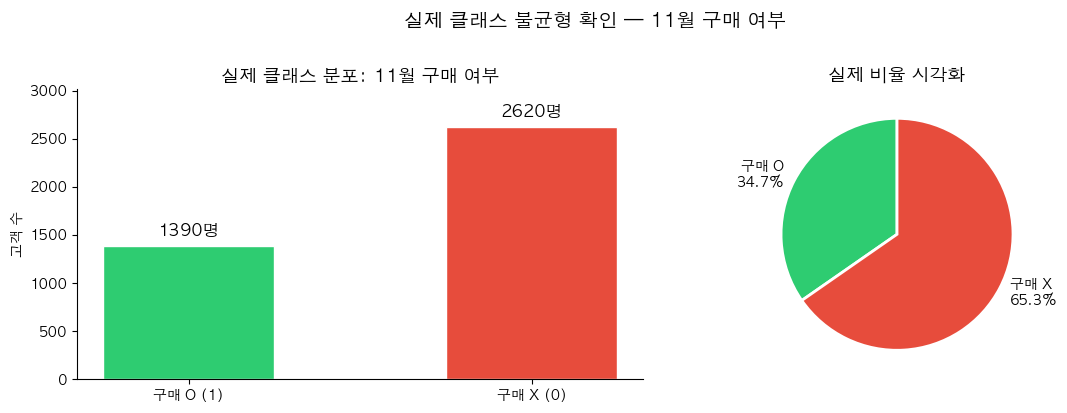

In [5]:
# ============================================================
# Cell 5 : 타겟 변수 생성 & 클래스 불균형 확인
# ============================================================

target_buyers = set(
    daily[
        (daily['Date'] >= TARGET_START) & (daily['Date'] <= TARGET_END)
    ]['CustomerID'].unique()
)

features['Target'] = features['CustomerID'].isin(target_buyers).astype(int)

n_pos  = features['Target'].sum()
n_neg  = len(features) - n_pos
n_total = len(features)
ratio   = n_pos / n_total

print(f"{'='*45}")
print(f"  {TARGET_LABEL} 분포")
print(f"{'='*45}")
print(f"  구매 O (1) : {n_pos:>5,}명  ({ratio*100:.1f}%)")
print(f"  구매 X (0) : {n_neg:>5,}명  ({(1-ratio)*100:.1f}%)")
print(f"  전체        : {n_total:>5,}명")
print(f"  불균형 비율 : 1 : {n_neg/n_pos:.1f}")
print(f"{'='*45}")

if ratio < 0.2:
    print('⚠️  심한 불균형 (< 20%) → class_weight 필수!')
elif ratio < 0.4:
    print('⚡ 중간 불균형 → class_weight 권장')
else:
    print('✅ 양호한 클래스 비율')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(['구매 O (1)', '구매 X (0)'], [n_pos, n_neg],
               color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%d명', padding=5, fontsize=12)
ax.set_title(f'실제 클래스 분포: {TARGET_LABEL}', fontsize=13, fontweight='bold')
ax.set_ylabel('고객 수')
ax.set_ylim(0, n_neg * 1.15)
ax.spines[['top','right']].set_visible(False)

ax2 = axes[1]
ax2.pie([n_pos, n_neg], labels=[f'구매 O\n{ratio*100:.1f}%', f'구매 X\n{(1-ratio)*100:.1f}%'],
        colors=['#2ecc71', '#e74c3c'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('실제 비율 시각화', fontsize=13, fontweight='bold')

plt.suptitle(f'실제 클래스 불균형 확인 — {TARGET_LABEL}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

월별 구매율 (학습 기간):
YearMonth  buyers     rate
  2010-12     948 0.236409
  2011-01     783 0.195262
  2011-02     798 0.199002
  2011-03    1020 0.254364
  2011-04     899 0.224190
  2011-05    1079 0.269077
  2011-06    1051 0.262095
  2011-07     993 0.247631
  2011-08     980 0.244389
  2011-09    1302 0.324688
  2011-10    1425 0.355362

[회귀 예측 결과]
  회귀 예측 11월 구매율 : 0.3251 (32.5%)
  실제    11월 구매율   : 0.3466 (34.7%)  ← 모델에 미사용

[회귀 결과에 따른 class_weight]
  구매X(0) 가중치 : 0.7409
  구매O(1) 가중치 : 1.5379
  XGBoost scale_pos_weight : 2.0758


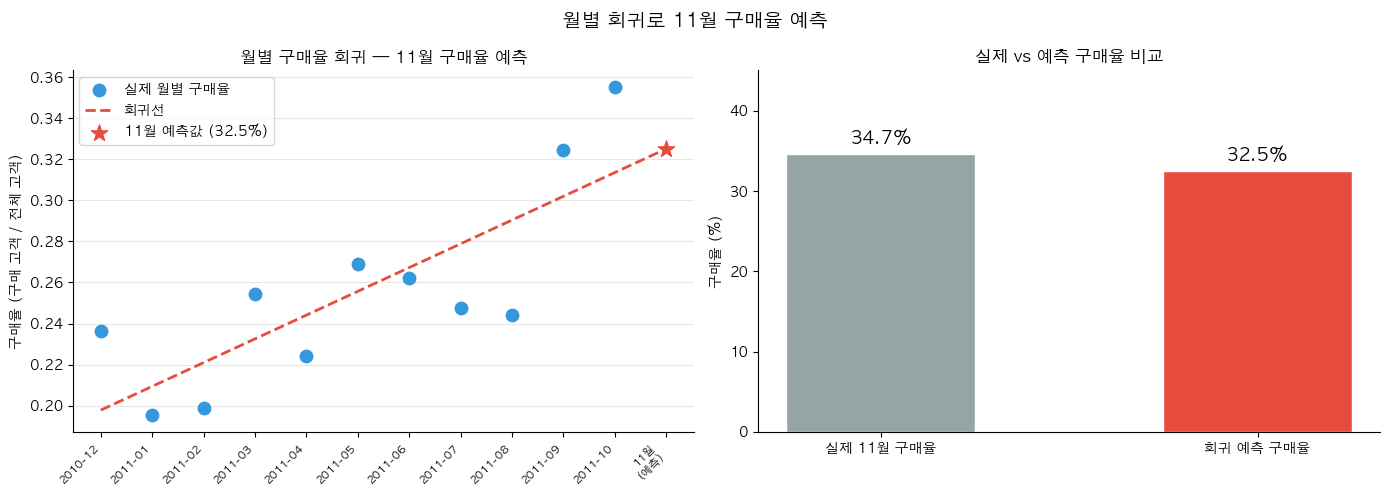

In [6]:
# ============================================================
# Cell 6 : 월별 구매율 회귀로 11월 구매율 예측
# ============================================================
# 실제 11월 구매율(35%)을 class_weight 계산에 직접 쓰면
# 11월 정보가 모델 구성에 간접 반영된다는 논란이 생김.
#
# 해결: 1~10월 월별 구매율로 LinearRegression을 돌려서
# '11월 구매율이 몇 %일 것이다'를 예측하고,
# 그 예측값으로 class_weight를 계산 → 실제 11월 분포 미사용

# ── 1. 피처 학습 기간의 전체 고객 수 ──
all_train_customers = daily[
    daily['Date'] <= FEATURE_CUTOFF
]['CustomerID'].nunique()

# ── 2. 월별 구매율 계산 (학습 기간 전체 월) ──
monthly_records = []
train_periods = (
    daily[daily['Date'] <= FEATURE_CUTOFF]
    .assign(YearMonth=lambda df: df['Date'].dt.to_period('M'))
    ['YearMonth'].sort_values().unique()
)

for idx, period in enumerate(train_periods):
    month_start = period.to_timestamp()
    month_end   = (period + 1).to_timestamp() - pd.Timedelta(days=1)
    buyers = daily[
        (daily['Date'] >= month_start) & (daily['Date'] <= month_end)
    ]['CustomerID'].nunique()
    rate = buyers / all_train_customers
    monthly_records.append({
        'YearMonth' : str(period),
        'month_num' : idx + 1,
        'rate'      : rate,
        'buyers'    : buyers
    })

monthly_df = pd.DataFrame(monthly_records)
print('월별 구매율 (학습 기간):')
print(monthly_df[['YearMonth','buyers','rate']].to_string(index=False))

# ── 3. LinearRegression으로 11월 구매율 예측 ──
lr_monthly = LinearRegression()
X_months = monthly_df['month_num'].values.reshape(-1, 1)
y_rates  = monthly_df['rate'].values
lr_monthly.fit(X_months, y_rates)

next_month_num      = len(monthly_df) + 1
predicted_pos_rate  = float(lr_monthly.predict([[next_month_num]])[0])
predicted_pos_rate  = np.clip(predicted_pos_rate, 0.05, 0.95)  # 극단값 방지
actual_pos_rate     = float(features['Target'].mean())          # 실제 11월 구매율 (비교용)

print(f'\n[회귀 예측 결과]')
print(f'  회귀 예측 11월 구매율 : {predicted_pos_rate:.4f} ({predicted_pos_rate*100:.1f}%)')
print(f'  실제    11월 구매율   : {actual_pos_rate:.4f} ({actual_pos_rate*100:.1f}%)  ← 모델에 미사용')

# ── 4. 예측값으로 class_weight 계산 ──
# 공식: w_c = 1 / (n_classes * predicted_rate_c)
pred_w1 = 1 / (2 * predicted_pos_rate)              # 구매O 가중치
pred_w0 = 1 / (2 * (1 - predicted_pos_rate))        # 구매X 가중치
predicted_class_weight = {0: pred_w0, 1: pred_w1}
pred_scale_pos = (1 - predicted_pos_rate) / predicted_pos_rate  # XGBoost용

print(f'\n[회귀 결과에 따른 class_weight]')
print(f'  구매X(0) 가중치 : {pred_w0:.4f}')
print(f'  구매O(1) 가중치 : {pred_w1:.4f}')
print(f'  XGBoost scale_pos_weight : {pred_scale_pos:.4f}')

# ── 5. 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 회귀선 그래프
ax = axes[0]
ax.scatter(monthly_df['month_num'], monthly_df['rate'],
           color='#3498db', s=80, zorder=5, label='실제 월별 구매율')
x_line = np.linspace(1, next_month_num, 100)
y_line = lr_monthly.predict(x_line.reshape(-1, 1))
ax.plot(x_line, y_line, color='#e74c3c', lw=2, linestyle='--', label='회귀선')
ax.scatter([next_month_num], [predicted_pos_rate],
           color='#e74c3c', s=150, zorder=6, marker='*',
           label=f'11월 예측값 ({predicted_pos_rate*100:.1f}%)')
ax.set_xticks(list(monthly_df['month_num']) + [next_month_num])
ax.set_xticklabels(
    list(monthly_df['YearMonth']) + ['11월\n(예측)'],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('구매율 (구매 고객 / 전체 고객)')
ax.set_title('월별 구매율 회귀 — 11월 구매율 예측', fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# 실제 vs 예측 비교 막대
ax2 = axes[1]
bars = ax2.bar(
    ['실제 11월 구매율', '회귀 예측 구매율'],
    [actual_pos_rate * 100, predicted_pos_rate * 100],
    color=['#95a5a6', '#e74c3c'], width=0.5, edgecolor='white'
)
ax2.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=13, fontweight='bold')
ax2.set_ylabel('구매율 (%)')
ax2.set_ylim(0, max(actual_pos_rate, predicted_pos_rate) * 100 * 1.3)
ax2.set_title('실제 vs 예측 구매율 비교', fontweight='bold')
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('월별 회귀로 11월 구매율 예측', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Cell 7 : Train / Test Split (Stratified 70 / 30)
# ============================================================
# stratify 유지
# → stratify는 Train/Test를 공평하게 나누는 것이지 class_weight에 쓰는 게 아님
# → class_weight는 위 셀에서 회귀 예측값(predicted_pos_rate)으로 계산했음

FEATURE_COLS = [
    'Recency', 'Frequency', 'Total_Amount', 'Avg_Amount',
    'Avg_Interval', 'Wait_Ratio', 'Freq_90d', 'Amount_90d', 'Segment'
]

X = features[FEATURE_COLS].values
y = features['Target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Train: {len(X_train):,}명  |  Test: {len(X_test):,}명")
print()
print('[Train 클래스 비율]')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  클래스 {u}: {c:,}명 ({c/len(y_train)*100:.1f}%)')
print()
print('[Test 클래스 비율]')
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  클래스 {u}: {c:,}명 ({c/len(y_test)*100:.1f}%)')
print()
print('✅ Stratified Split 완료')
print(f'✅ class_weight는 회귀 예측값({predicted_pos_rate*100:.1f}%) 기반 — 실제 11월 미사용')

Train: 2,807명  |  Test: 1,203명

[Train 클래스 비율]
  클래스 0: 1,834명 (65.3%)
  클래스 1: 973명 (34.7%)

[Test 클래스 비율]
  클래스 0: 786명 (65.3%)
  클래스 1: 417명 (34.7%)

✅ Stratified Split 완료
✅ class_weight는 회귀 예측값(32.5%) 기반 — 실제 11월 미사용


In [8]:
# ============================================================
# Cell 7 : 스케일링 — SMOTE 제거, class_weight 방식으로 대체
# ============================================================
#
# [교수님 피드백 및 동환오빠 의견 반영] SMOTE 제거 이유
# SMOTE는 Train set에만 적용해야 하는데, Test set의 클래스 비율(35:65)을
# '기준'으로 삼아 Train set을 가공하면 Test 정보가 Train 구성에 영향을 주는
# 간접적 Data Leakage 논란이 생김.
#
# [대안] 각 모델에 class_weight='balanced' / scale_pos_weight 파라미터 사용
# → 모델이 내부적으로 소수 클래스(구매 O)에 높은 가중치를 부여해 학습
# → 데이터 자체를 건드리지 않으므로 더 안전한 접근

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Train으로만 fit
X_test_scaled  = scaler.transform(X_test)        # Test는 transform만

# 변수명 통일 (이후 셀에서 X_train_res, y_train_res 그대로 사용)
X_train_res = X_train_scaled
y_train_res = y_train

print(f"Train 크기: {X_train_res.shape}")
print(f"Test  크기: {X_test_scaled.shape}  (건드리지 않음)")
print()
print('[Train 클래스 비율 — 원본 그대로 유지]')
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  클래스 {u}: {c:,}명 ({c/len(y_train_res)*100:.1f}%)')
print()
print('✅ SMOTE 미적용 → class_weight 파라미터로 불균형 처리')

Train 크기: (2807, 9)
Test  크기: (1203, 9)  (건드리지 않음)

[Train 클래스 비율 — 원본 그대로 유지]
  클래스 0: 1,834명 (65.3%)
  클래스 1: 973명 (34.7%)

✅ SMOTE 미적용 → class_weight 파라미터로 불균형 처리


In [9]:
# ============================================================
# Cell 9 : 모델 정의 — class_weight 적용
# ============================================================
# class_weight='balanced' → 실제 Train 분포(11월 데이터) 기반
# predicted_class_weight  → 회귀 예측값 기반 (11월 실제 분포 미사용) ✅

print(f"class_weight: { {k: round(float(v), 4) for k, v in predicted_class_weight.items()} }")
print(f"XGBoost scale_pos_weight: {pred_scale_pos:.4f}")
print()

models = {
    'Logistic Regression': LogisticRegression(
        class_weight=predicted_class_weight,
        max_iter=1000,
        random_state=42,
        C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight=predicted_class_weight,
        max_depth=None,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    'HistGradient Boosting': HistGradientBoostingClassifier(
        max_iter=300,
        class_weight=predicted_class_weight,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
}

if XGB_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=300,
        scale_pos_weight=pred_scale_pos,
        learning_rate=0.05,
        max_depth=5,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

if LGBM_AVAILABLE:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=300,
        class_weight=predicted_class_weight,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

print(f'총 {len(models)}개 모델 준비 완료:')
for name in models:
    print(f'  • {name}')

class_weight: {0: 0.7409, 1: 1.5379}
XGBoost scale_pos_weight: 2.0758

총 5개 모델 준비 완료:
  • Logistic Regression
  • Random Forest
  • HistGradient Boosting
  • XGBoost
  • LightGBM


In [10]:
# ============================================================
# Cell 9 : Hyperparameter Tuning — RandomizedSearchCV
# ============================================================
# [목적]
# 이전 결과에서 복잡한 트리 모델(RF, XGB, LGBM)의 CV 점수가 높은데
# Test 점수는 Logistic Regression보다 낮은 현상 → 과적합(Overfitting)
# 기본 파라미터(max_depth=None, n_estimators=300 등)가 너무 복잡한 모델을
# 만들어 Train 데이터에 과적합하기 때문
#
# [해결] RandomizedSearchCV로 각 모델의 최적 파라미터를 탐색 (Hyperparameter Tuning)
# - Inner CV: StratifiedKFold(5) — Train set 내에서만 수행 (Test 미사용)
# - 탐색 후 best_estimator_ 로 models 딕셔너리 교체
# - scoring='roc_auc' 기준으로 최적화

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_models = {}   # 튜닝 완료 모델 저장

# ── 1. Logistic Regression ──
# 탐색 파라미터: C (규제 강도) — 작을수록 규제 강함 → 단순한 모델
lr_param = {
    'C': loguniform(1e-3, 1e2),  # 0.001 ~ 100 사이 로그 균등 분포
    'solver': ['lbfgs', 'saga']
}
lr_search = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    param_distributions=lr_param,
    n_iter=20, cv=inner_cv, scoring='roc_auc',
    random_state=42, n_jobs=-1, refit=True
)
lr_search.fit(X_train_res, y_train_res)
tuned_models['Logistic Regression'] = lr_search.best_estimator_
print(f"[LR]  최적 C={lr_search.best_params_['C']:.4f}, "
      f"solver={lr_search.best_params_['solver']}, "
      f"CV AUC={lr_search.best_score_:.4f}")

# ── 2. Random Forest ──
# 핵심 파라미터: max_depth (깊이 제한), n_estimators, min_samples_leaf
# max_depth=None이 과적합의 주범 → 깊이 제한으로 일반화 성능 향상
rf_param = {
    'n_estimators': randint(100, 500),
    'max_depth'   : [3, 4, 5, 6, 7, 8, None],
    'min_samples_leaf': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=rf_param,
    n_iter=30, cv=inner_cv, scoring='roc_auc',
    random_state=42, n_jobs=-1, refit=True
)
rf_search.fit(X_train_res, y_train_res)
tuned_models['Random Forest'] = rf_search.best_estimator_
print(f"[RF]  최적 파라미터: {rf_search.best_params_}, CV AUC={rf_search.best_score_:.4f}")

# ── 3. HistGradientBoosting ──
hgb_param = {
    'max_iter'       : [100, 200, 300, 500],
    'learning_rate'  : loguniform(1e-3, 0.3),
    'max_depth'      : [3, 4, 5, 6, None],
    'min_samples_leaf': randint(5, 50),
    'l2_regularization': uniform(0, 1),
}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
    param_distributions=hgb_param,
    n_iter=30, cv=inner_cv, scoring='roc_auc',
    random_state=42, n_jobs=-1, refit=True
)
hgb_search.fit(X_train_res, y_train_res)
tuned_models['HistGradient Boosting'] = hgb_search.best_estimator_
print(f"[HGB] 최적 파라미터: {hgb_search.best_params_}, CV AUC={hgb_search.best_score_:.4f}")

# ── 4. XGBoost (설치된 경우) ──
if XGB_AVAILABLE:
    xgb_param = {
        'n_estimators'     : randint(100, 500),
        'max_depth'        : [3, 4, 5, 6],
        'learning_rate'    : loguniform(1e-3, 0.3),
        'subsample'        : uniform(0.6, 0.4),
        'colsample_bytree' : uniform(0.6, 0.4),
        'reg_alpha'        : loguniform(1e-4, 10),
        'reg_lambda'       : loguniform(1e-4, 10),
    }
    xgb_search = RandomizedSearchCV(
        XGBClassifier(
            scale_pos_weight=pred_scale_pos,
            eval_metric='logloss', random_state=42, n_jobs=-1
        ),
        param_distributions=xgb_param,
        n_iter=30, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )
    xgb_search.fit(X_train_res, y_train_res)
    tuned_models['XGBoost'] = xgb_search.best_estimator_
    print(f"[XGB] 최적 파라미터: {xgb_search.best_params_}, CV AUC={xgb_search.best_score_:.4f}")

# ── 5. LightGBM (설치된 경우) ──
if LGBM_AVAILABLE:
    lgb_param = {
        'n_estimators'  : randint(100, 500),
        'max_depth'     : [3, 4, 5, 6, -1],
        'learning_rate' : loguniform(1e-3, 0.3),
        'num_leaves'    : randint(15, 63),
        'subsample'     : uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha'     : loguniform(1e-4, 10),
        'reg_lambda'    : loguniform(1e-4, 10),
    }
    lgb_search = RandomizedSearchCV(
        LGBMClassifier(
            is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1
        ),
        param_distributions=lgb_param,
        n_iter=30, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )
    lgb_search.fit(X_train_res, y_train_res)
    tuned_models['LightGBM'] = lgb_search.best_estimator_
    print(f"[LGB] 최적 파라미터: {lgb_search.best_params_}, CV AUC={lgb_search.best_score_:.4f}")

# ── models 딕셔너리를 튜닝된 모델로 교체 ──
models = tuned_models
print(f"\n✅ Hyperparameter Tuning 완료 — {len(models)}개 모델 갱신")
print('   이후 셀에서는 튜닝된 모델로 CV 및 Test 평가 진행')

[LR]  최적 C=0.0050, solver=saga, CV AUC=0.7566
[RF]  최적 파라미터: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 13, 'n_estimators': 413}, CV AUC=0.7683
[HGB] 최적 파라미터: {'l2_regularization': np.float64(0.8804678390152577), 'learning_rate': np.float64(0.035204702862431825), 'max_depth': 3, 'max_iter': 100, 'min_samples_leaf': 10}, CV AUC=0.7608
[XGB] 최적 파라미터: {'colsample_bytree': np.float64(0.7292811728083021), 'learning_rate': np.float64(0.019280010934335175), 'max_depth': 3, 'n_estimators': 279, 'reg_alpha': np.float64(0.0065788201191231774), 'reg_lambda': np.float64(7.226207258080486), 'subsample': np.float64(0.9849789179768444)}, CV AUC=0.7675
[LGB] 최적 파라미터: {'colsample_bytree': np.float64(0.6478376983753207), 'learning_rate': np.float64(0.058451252572625234), 'max_depth': 3, 'n_estimators': 104, 'num_leaves': 40, 'reg_alpha': np.float64(0.0015132984900630335), 'reg_lambda': np.float64(0.0019069601332062707), 'subsample': np.float64(0.6161734358153725

In [11]:
# ============================================================
# Cell 10 : Cross Validation (Stratified K-Fold, k=5)
# ============================================================
# StratifiedKFold: 각 Fold의 클래스 비율을 원본과 동일하게 유지
# → 불균형 데이터에서 필수!
#
# 평가 지표:
#   ROC-AUC : 불균형 데이터 주요 지표 (Threshold 무관)
#   F1 (macro) : Precision·Recall의 조화평균
#   Accuracy : 참고용 (불균형에서 오해 유발 가능)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Cross Validation 실행 중...')
print(f"{'='*58}")
print(f"{'모델명':<25} {'ROC-AUC':>10} {'F1(macro)':>10} {'Accuracy':>10}")
print(f"{'-'*58}")

for name, model in models.items():
    cv_score = cross_validate(
        model,
        X_train_res, y_train_res,
        cv=cv,
        scoring=['roc_auc', 'f1_macro', 'accuracy'],
        n_jobs=-1
    )
    cv_results[name] = {
        'ROC-AUC'  : cv_score['test_roc_auc'],
        'F1_macro' : cv_score['test_f1_macro'],
        'Accuracy' : cv_score['test_accuracy'],
    }
    print(
        f"{name:<25}"
        f"  {cv_score['test_roc_auc'].mean():.4f}±{cv_score['test_roc_auc'].std():.3f}"
        f"  {cv_score['test_f1_macro'].mean():.4f}±{cv_score['test_f1_macro'].std():.3f}"
        f"  {cv_score['test_accuracy'].mean():.4f}±{cv_score['test_accuracy'].std():.3f}"
    )

print(f"{'='*58}")
print('\n📌 포맷: 평균 ± 표준편차')

Cross Validation 실행 중...
모델명                          ROC-AUC  F1(macro)   Accuracy
----------------------------------------------------------
Logistic Regression        0.7566±0.012  0.6869±0.006  0.7032±0.007
Random Forest              0.7683±0.008  0.6985±0.013  0.7196±0.017
HistGradient Boosting      0.7608±0.010  0.6982±0.011  0.7196±0.015
XGBoost                    0.7675±0.008  0.6935±0.008  0.7121±0.012
LightGBM                   0.7648±0.007  0.6971±0.009  0.7186±0.012

📌 포맷: 평균 ± 표준편차


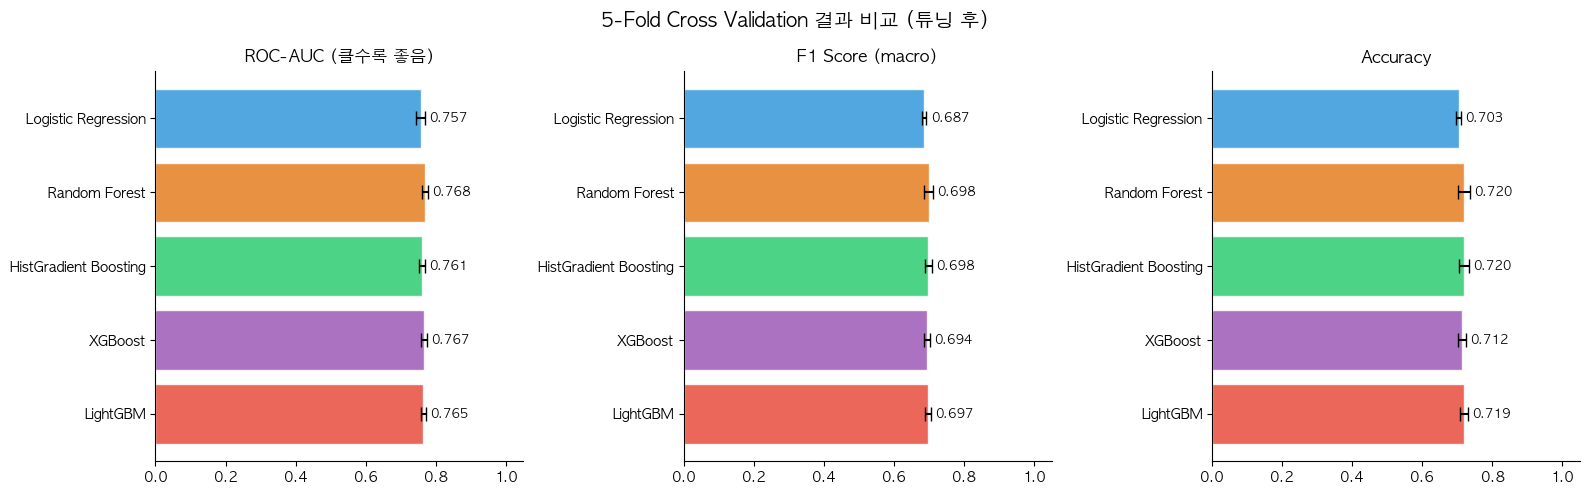


🏆 CV 기준 최고 모델 (ROC-AUC): Random Forest


In [12]:
# ============================================================
# Cell 11 : CV 결과 시각화
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['ROC-AUC', 'F1_macro', 'Accuracy']
titles  = ['ROC-AUC (클수록 좋음)', 'F1 Score (macro)', 'Accuracy']
colors  = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c']

for ax, metric, title in zip(axes, metrics, titles):
    names  = list(cv_results.keys())
    means  = [cv_results[n][metric].mean() for n in names]
    stds   = [cv_results[n][metric].std()  for n in names]

    bars = ax.barh(names, means, xerr=stds,
                   color=colors[:len(names)], alpha=0.85,
                   edgecolor='white', capsize=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.bar_label(bars, labels=[f'{m:.3f}' for m in means],
                 padding=3, fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.invert_yaxis()

plt.suptitle('5-Fold Cross Validation 결과 비교 (튜닝 후)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_by_auc = max(cv_results, key=lambda n: cv_results[n]['ROC-AUC'].mean())
print(f"\n🏆 CV 기준 최고 모델 (ROC-AUC): {best_by_auc}")

In [13]:
# ============================================================
# Cell 12 : 앙상블 모델
# ============================================================

sorted_models = sorted(
    cv_results.items(),
    key=lambda x: x[1]['ROC-AUC'].mean(),
    reverse=True
)
top3_names = [name for name, _ in sorted_models[:3]]
print(f"앙상블 구성 모델 (상위 3개): {top3_names}")

ensemble_estimators = [(name, models[name]) for name in top3_names]

ensemble = VotingClassifier(
    estimators=ensemble_estimators,
    voting='soft',
    n_jobs=-1
)

ensemble_cv = cross_validate(
    ensemble,
    X_train_res, y_train_res,
    cv=cv,
    scoring=['roc_auc', 'f1_macro', 'accuracy'],
    n_jobs=-1
)
print(f"\n앙상블 CV 결과:")
print(f"  ROC-AUC  : {ensemble_cv['test_roc_auc'].mean():.4f} ± {ensemble_cv['test_roc_auc'].std():.4f}")
print(f"  F1(macro): {ensemble_cv['test_f1_macro'].mean():.4f} ± {ensemble_cv['test_f1_macro'].std():.4f}")
print(f"  Accuracy : {ensemble_cv['test_accuracy'].mean():.4f} ± {ensemble_cv['test_accuracy'].std():.4f}")

cv_results['Ensemble (Voting)'] = {
    'ROC-AUC'  : ensemble_cv['test_roc_auc'],
    'F1_macro' : ensemble_cv['test_f1_macro'],
    'Accuracy' : ensemble_cv['test_accuracy'],
}

앙상블 구성 모델 (상위 3개): ['Random Forest', 'XGBoost', 'LightGBM']

앙상블 CV 결과:
  ROC-AUC  : 0.7679 ± 0.0082
  F1(macro): 0.6981 ± 0.0118
  Accuracy : 0.7186 ± 0.0155


In [14]:
# ============================================================
# Cell 13 : 모든 모델 Test Set 최종 평가
# ============================================================
all_models = dict(models)
all_models['Ensemble (Voting)'] = ensemble

test_results = {}

for name, model in all_models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    test_results[name] = {
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'roc_auc'  : roc_auc_score(y_test, y_prob),
        'f1_macro' : f1_score(y_test, y_pred, average='macro'),
        'f1_class1': f1_score(y_test, y_pred, average='binary'),
    }

print(f"{'='*65}")
print(f"{'모델명':<25} {'ROC-AUC':>10} {'F1(macro)':>10} {'F1(구매O)':>10}")
print(f"{'-'*65}")
for name, res in test_results.items():
    print(f"{name:<25}  {res['roc_auc']:>9.4f}  {res['f1_macro']:>9.4f}  {res['f1_class1']:>9.4f}")
print(f"{'='*65}")

best_model_name = max(test_results, key=lambda n: test_results[n]['roc_auc'])
print(f"\n🏆 Test 기준 최고 모델 (ROC-AUC): {best_model_name}")

모델명                          ROC-AUC  F1(macro)    F1(구매O)
-----------------------------------------------------------------
Logistic Regression           0.7128     0.6496     0.5652
Random Forest                 0.7121     0.6528     0.5587
HistGradient Boosting         0.7069     0.6582     0.5656
XGBoost                       0.7070     0.6527     0.5664
LightGBM                      0.7049     0.6550     0.5593
Ensemble (Voting)             0.7081     0.6553     0.5630

🏆 Test 기준 최고 모델 (ROC-AUC): Logistic Regression


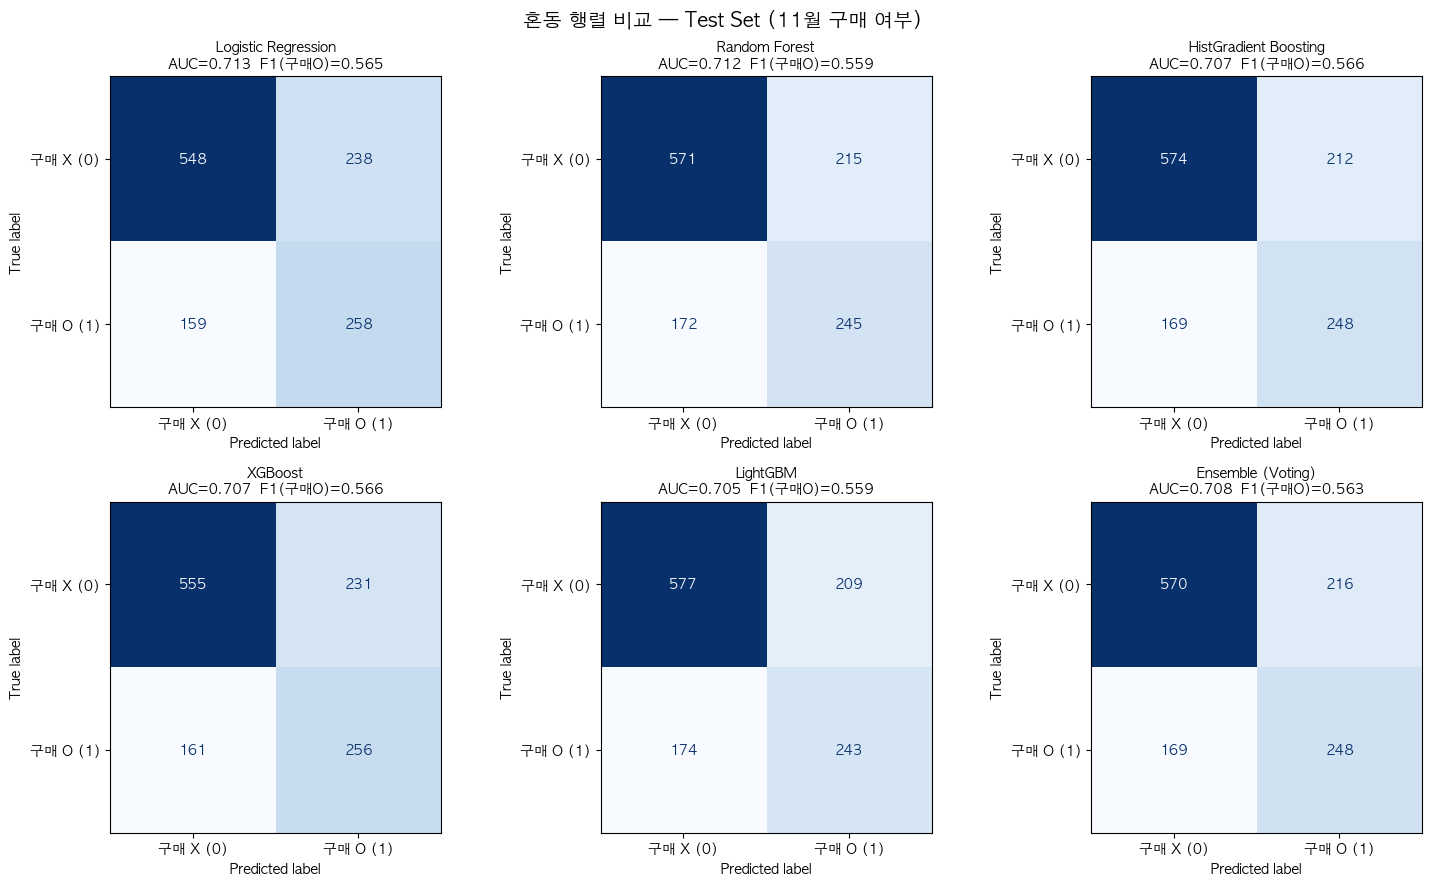

[읽는 법]
  왼쪽 위 (TN) : 실제 미구매 → 미구매 예측 ✅
  오른쪽 위 (FP): 실제 미구매 → 구매 예측  ❌ (False Alarm)
  왼쪽 아래 (FN): 실제 구매   → 미구매 예측 ❌ (놓친 고객)
  오른쪽 아래 (TP): 실제 구매 → 구매 예측  ✅


In [15]:
# ============================================================
# Cell 14 : 혼동 행렬 (Confusion Matrix) — 전체 모델
# ============================================================
n_models = len(all_models)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))
axes = axes.flatten()

for idx, (name, res) in enumerate(test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['구매 X (0)', '구매 O (1)'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(
        f"{name}\nAUC={res['roc_auc']:.3f}  F1(구매O)={res['f1_class1']:.3f}",
        fontsize=10, fontweight='bold'
    )

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'혼동 행렬 비교 — Test Set ({TARGET_LABEL})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('[읽는 법]')
print('  왼쪽 위 (TN) : 실제 미구매 → 미구매 예측 ✅')
print('  오른쪽 위 (FP): 실제 미구매 → 구매 예측  ❌ (False Alarm)')
print('  왼쪽 아래 (FN): 실제 구매   → 미구매 예측 ❌ (놓친 고객)')
print('  오른쪽 아래 (TP): 실제 구매 → 구매 예측  ✅')

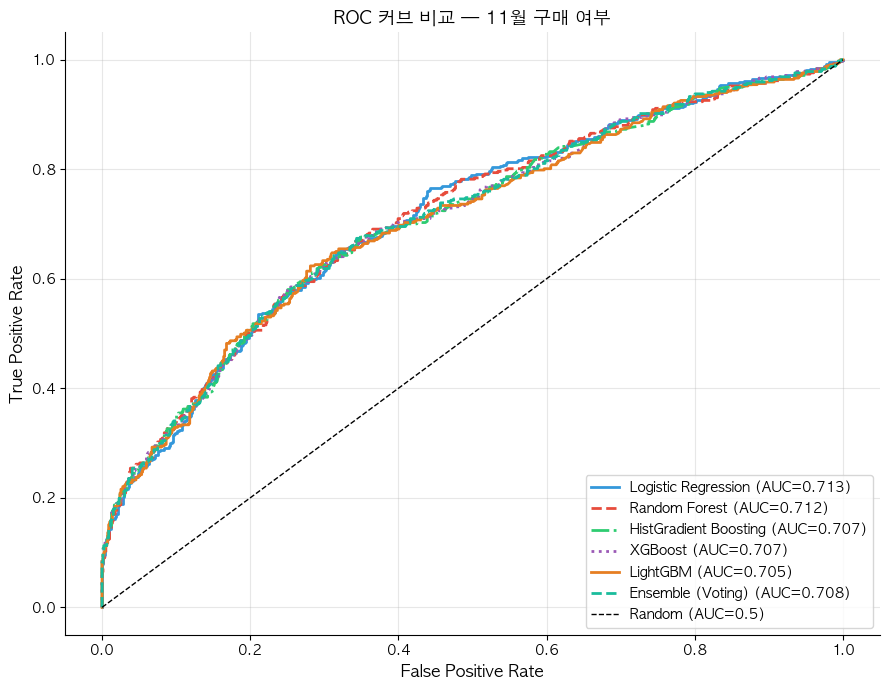

In [16]:
# ============================================================
# Cell 15 : ROC 커브 비교
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#e67e22', '#1abc9c']
linestyles = ['-', '--', '-.', ':', '-', '--']

for idx, (name, res) in enumerate(test_results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr,
            color=colors_roc[idx % len(colors_roc)],
            linestyle=linestyles[idx % len(linestyles)],
            lw=2,
            label=f"{name} (AUC={res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC 커브 비교 — {TARGET_LABEL}', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Cell 16 : Best Model 상세 리포트
# ============================================================
print(f"\n{'='*50}")
print(f"  🏆 최고 성능 모델: {best_model_name}")
print(f"{'='*50}")

y_pred_best = test_results[best_model_name]['y_pred']
print()
print(classification_report(
    y_test, y_pred_best,
    target_names=['구매 X (0)', '구매 O (1)'],
    digits=4
))
print(f"ROC-AUC: {test_results[best_model_name]['roc_auc']:.4f}")

print()
print('[마케팅 관점 해석 / 아직 Threshold 미설정]')
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
precision_pos = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_pos    = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f'  Precision(구매O): {precision_pos:.3f} → 구매 예측 고객 중 실제 구매 비율')
print(f'  Recall(구매O)   : {recall_pos:.3f}    → 실제 구매 고객 중 발굴한 비율')
print(f'  → 마케팅 쿠폰 발송 시 Precision 높을수록 비용 효율 좋음')
print(f'  → 이탈 방지 캠페인 시 Recall 높을수록 놓치는 고객 적음')


  🏆 최고 성능 모델: Logistic Regression

              precision    recall  f1-score   support

    구매 X (0)     0.7751    0.6972    0.7341       786
    구매 O (1)     0.5202    0.6187    0.5652       417

    accuracy                         0.6700      1203
   macro avg     0.6476    0.6580    0.6496      1203
weighted avg     0.6867    0.6700    0.6755      1203

ROC-AUC: 0.7128

[마케팅 관점 해석 / 아직 Threshold 미설정]
  Precision(구매O): 0.520 → 구매 예측 고객 중 실제 구매 비율
  Recall(구매O)   : 0.619    → 실제 구매 고객 중 발굴한 비율
  → 마케팅 쿠폰 발송 시 Precision 높을수록 비용 효율 좋음
  → 이탈 방지 캠페인 시 Recall 높을수록 놓치는 고객 적음


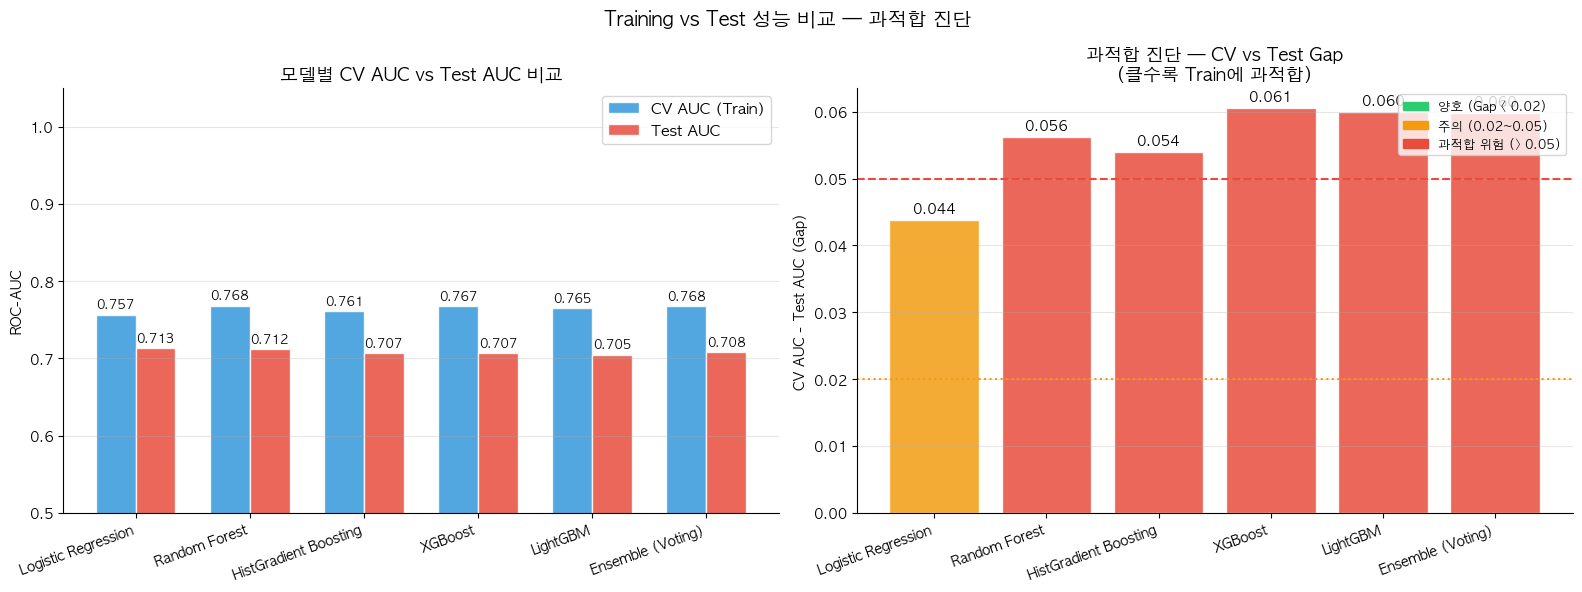

[해석]
  CV AUC  : Training set 내 5-Fold 교차검증 평균 성능
  Test AUC: 한 번도 본 적 없는 Test set 성능
  Gap이 클수록 → Train 데이터에 과적합된 것
  Hyperparameter Tuning 전/후 Gap 변화로 개선 효과 확인 가능


In [18]:
# ============================================================
# Cell 17 : Train vs Test 성능 비교 — 과적합 진단
# ============================================================
# 교수님 요청 반영: Training set과 Test set 결과를 한눈에 비교
# ROC 커브 대신 → 모델별 CV(Train) AUC vs Test AUC 막대 비교
# → 두 값의 차이(Gap)가 클수록 과적합 의심

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names_list = list(cv_results.keys())
cv_aucs   = [cv_results[n]['ROC-AUC'].mean() for n in model_names_list]
test_aucs = [test_results[n]['roc_auc'] if n in test_results else 0
             for n in model_names_list]
gaps      = [cv - te for cv, te in zip(cv_aucs, test_aucs)]

x = np.arange(len(model_names_list))
width = 0.35

# ── 왼쪽: CV AUC vs Test AUC 막대 비교 ──
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, cv_aucs,   width, label='CV AUC (Train)',
                color='#3498db', alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + width/2, test_aucs, width, label='Test AUC',
                color='#e74c3c', alpha=0.85, edgecolor='white')
ax1.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax1.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(model_names_list, rotation=20, ha='right', fontsize=10)
ax1.set_ylabel('ROC-AUC')
ax1.set_ylim(0.5, 1.05)
ax1.set_title('모델별 CV AUC vs Test AUC 비교', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# ── 오른쪽: Overfitting Gap (CV - Test) ──
ax2 = axes[1]
colors_gap = ['#e74c3c' if g > 0.05 else '#f39c12' if g > 0.02 else '#2ecc71'
              for g in gaps]
bars3 = ax2.bar(model_names_list, gaps, color=colors_gap,
                edgecolor='white', alpha=0.85)
ax2.bar_label(bars3, fmt='%.3f', padding=3, fontsize=10)
ax2.axhline(y=0.05, color='#e74c3c', linestyle='--', lw=1.5,
            label='과적합 경계 (0.05)')
ax2.axhline(y=0.02, color='#f39c12', linestyle=':', lw=1.5,
            label='주의 구간 (0.02)')
ax2.set_xticks(range(len(model_names_list)))
ax2.set_xticklabels(model_names_list, rotation=20, ha='right', fontsize=10)
ax2.set_ylabel('CV AUC - Test AUC (Gap)')
ax2.set_title('과적합 진단 — CV vs Test Gap\n'  
              '(클수록 Train에 과적합)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

# 색상 범례 설명
from matplotlib.patches import Patch
legend_els = [
    Patch(color='#2ecc71', label='양호 (Gap < 0.02)'),
    Patch(color='#f39c12', label='주의 (0.02~0.05)'),
    Patch(color='#e74c3c', label='과적합 위험 (> 0.05)'),
]
ax2.legend(handles=legend_els, fontsize=9, loc='upper right')

plt.suptitle('Training vs Test 성능 비교 — 과적합 진단',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('[해석]')
print('  CV AUC  : Training set 내 5-Fold 교차검증 평균 성능')
print('  Test AUC: 한 번도 본 적 없는 Test set 성능')
print('  Gap이 클수록 → Train 데이터에 과적합된 것')
print('  Hyperparameter Tuning 전/후 Gap 변화로 개선 효과 확인 가능')

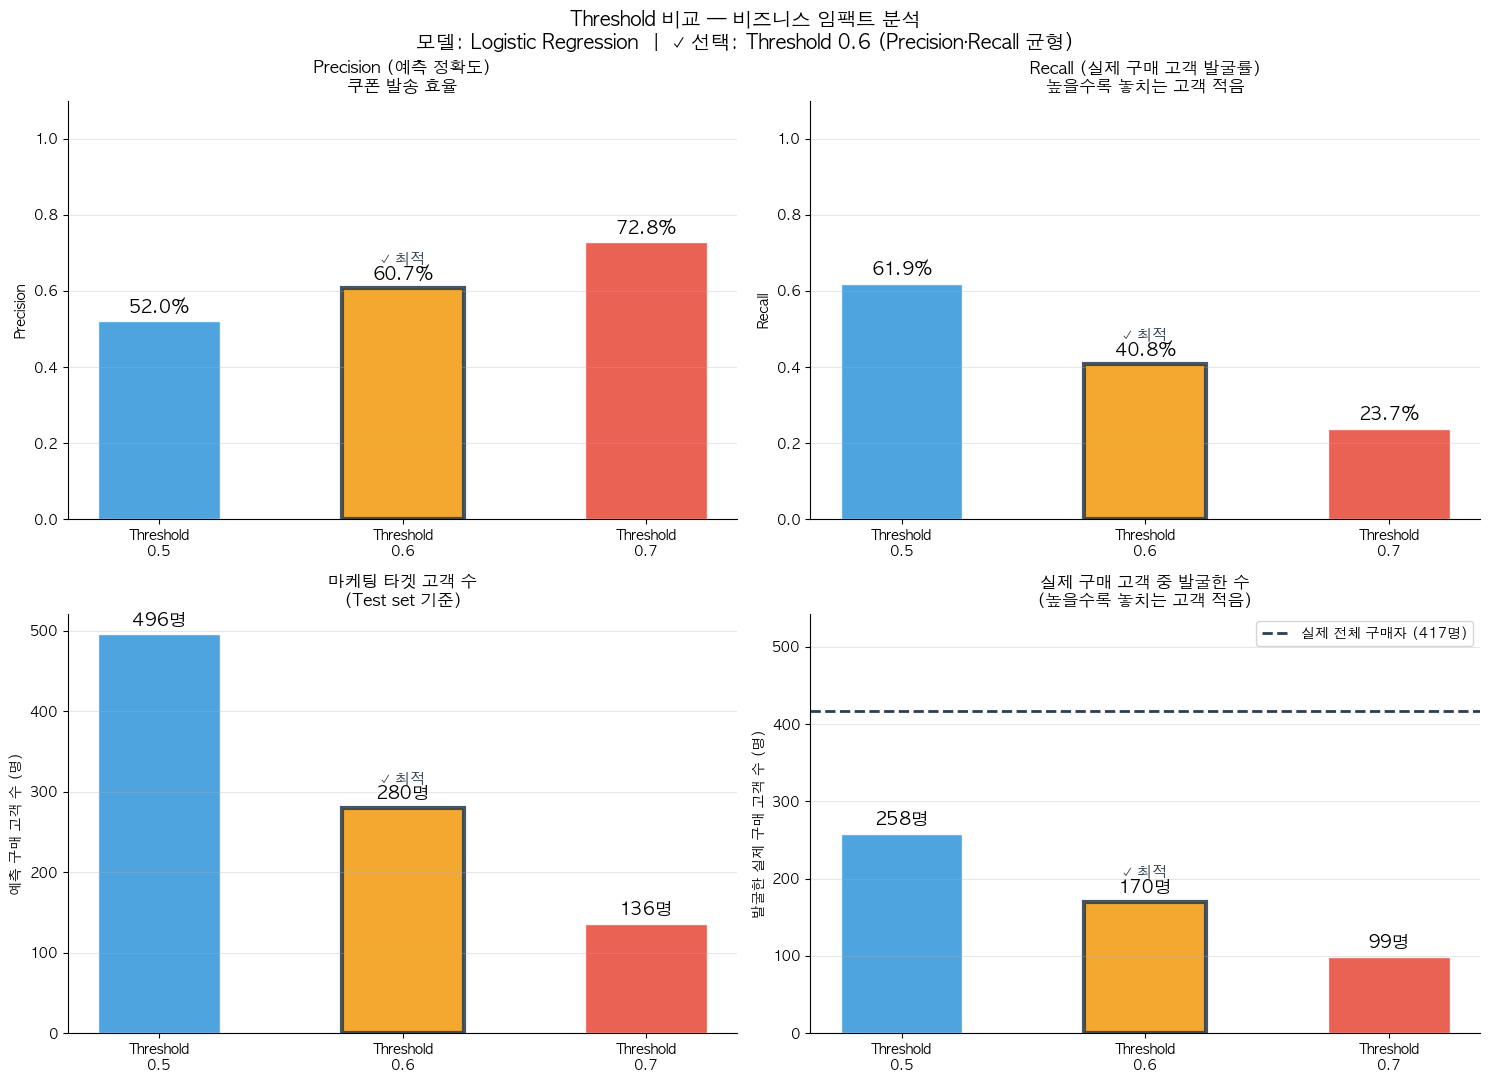

  Threshold별 비즈니스 임팩트 비교 — Logistic Regression
 Threshold  Precision     Recall      타겟수       발굴 구매자       1000명 발송시 구매
----------------------------------------------------------------------
       0.5     0.5202     0.6187      496명       258명            520명
       0.6     0.6071     0.4077      280명       170명            607명  ← 선택
       0.7     0.7279     0.2374      136명        99명            727명
     랜덤 발송     0.3466         -              -              -      346명  ← 기준선

[발표 핵심 메시지]
  Threshold 0.5: 쿠폰 1,000장 → 520명 구매 (랜덤 대비 +174명), 실제 구매자 중 159명 미타겟
  Threshold 0.6: 쿠폰 1,000장 → 607명 구매 (랜덤 대비 +261명), 실제 구매자 중 247명 미타겟  ← 선택 (균형점)
  Threshold 0.7: 쿠폰 1,000장 → 727명 구매 (랜덤 대비 +381명), 실제 구매자 중 318명 미타겟


In [19]:
# ============================================================
# Cell 18 : Threshold 3-way 비교 — 비즈니스 발표용
# ============================================================
from sklearn.metrics import precision_recall_curve

y_prob_best = test_results[best_model_name]['y_prob']
THRESHOLDS  = [0.5, 0.6, 0.7]
THR_COLORS  = ['#3498db', '#f39c12', '#e74c3c']
CHOSEN_THR  = 0.6   # ← 선택한 threshold

# ── 각 threshold별 지표 계산 ──
thr_stats = []
for thr in THRESHOLDS:
    y_pred_t = (y_prob_best >= thr).astype(int)
    tp = ((y_pred_t==1) & (y_test==1)).sum()
    fp = ((y_pred_t==1) & (y_test==0)).sum()
    fn = ((y_pred_t==0) & (y_test==1)).sum()
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    n_target = int(y_pred_t.sum())
    buyers_per_1000 = int(prec * 1000)
    thr_stats.append({
        'threshold'      : thr,
        'precision'      : prec,
        'recall'         : rec,
        'f1'             : f1,
        'n_target'       : n_target,
        'buyers_per_1000': buyers_per_1000,
    })

# ── 선택한 threshold 인덱스 ──
chosen_idx = THRESHOLDS.index(CHOSEN_THR)

# ── 강조 헬퍼 함수 ──
def highlight_bars(ax, bars, chosen_idx):
    for i, bar in enumerate(bars):
        if i == chosen_idx:
            bar.set_edgecolor('#2c3e50')
            bar.set_linewidth(3)
            ax.annotate('✓ 최적',
                        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        xytext=(0, 18), textcoords='offset points',
                        ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

# ── 시각화 ──
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
labels = [f'Threshold\n{t}' for t in THRESHOLDS]

# [1] Precision 비교
ax = axes[0, 0]
precs = [s['precision'] for s in thr_stats]
bars = ax.bar(labels, precs, color=THR_COLORS, edgecolor='white', width=0.5, alpha=0.88)
ax.bar_label(bars, labels=[f'{p*100:.1f}%' for p in precs],
             padding=4, fontsize=13, fontweight='bold')
highlight_bars(ax, bars, chosen_idx)
ax.set_title('Precision (예측 정확도)\n쿠폰 발송 효율', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision')
ax.set_ylim(0, 1.1)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# [2] Recall 비교
ax = axes[0, 1]
recs = [s['recall'] for s in thr_stats]
bars = ax.bar(labels, recs, color=THR_COLORS, edgecolor='white', width=0.5, alpha=0.88)
ax.bar_label(bars, labels=[f'{r*100:.1f}%' for r in recs],
             padding=4, fontsize=13, fontweight='bold')
highlight_bars(ax, bars, chosen_idx)
ax.set_title('Recall (실제 구매 고객 발굴률)\n높을수록 놓치는 고객 적음', fontsize=12, fontweight='bold')
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.1)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# [3] 타겟 고객 수 비교
ax = axes[1, 0]
n_targets = [s['n_target'] for s in thr_stats]
bars = ax.bar(labels, n_targets, color=THR_COLORS, edgecolor='white', width=0.5, alpha=0.88)
ax.bar_label(bars, labels=[f'{n:,}명' for n in n_targets],
             padding=4, fontsize=13, fontweight='bold')
highlight_bars(ax, bars, chosen_idx)
ax.set_title('마케팅 타겟 고객 수\n(Test set 기준)', fontsize=12, fontweight='bold')
ax.set_ylabel('예측 구매 고객 수 (명)')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# [4] 실제 발굴 구매 고객 수 (수정된 부분)
ax = axes[1, 1]
total_buyers = int(y_test.sum())
caught_buyers = [int(s['recall'] * total_buyers) for s in thr_stats]
bars = ax.bar(labels, caught_buyers, color=THR_COLORS, edgecolor='white', width=0.5, alpha=0.88)
ax.bar_label(bars, labels=[f'{b}명' for b in caught_buyers],
             padding=4, fontsize=13, fontweight='bold')
highlight_bars(ax, bars, chosen_idx)
ax.axhline(y=total_buyers, color='#2c3e50', linestyle='--', lw=2,
           label=f'실제 전체 구매자 ({total_buyers}명)')
ax.set_title('실제 구매 고객 중 발굴한 수\n(높을수록 놓치는 고객 적음)', fontsize=12, fontweight='bold')
ax.set_ylabel('발굴한 실제 구매 고객 수 (명)')
ax.set_ylim(0, total_buyers * 1.3)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Threshold 비교 — 비즈니스 임팩트 분석\n'
             f'모델: {best_model_name}  |  ✓ 선택: Threshold {CHOSEN_THR} (Precision·Recall 균형)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 요약 테이블 ──
actual_rate = float(features['Target'].mean())
print(f"{'='*70}")
print(f"  Threshold별 비즈니스 임팩트 비교 — {best_model_name}")
print(f"{'='*70}")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} "
      f"{'타겟수':>8} {'발굴 구매자':>12} {'1000명 발송시 구매':>18}")
print(f"{'-'*70}")
for s, caught in zip(thr_stats, caught_buyers):
    marker = '  ← 선택' if s['threshold'] == CHOSEN_THR else ''
    print(f"{s['threshold']:>10.1f} {s['precision']:>10.4f} {s['recall']:>10.4f} "
          f"{s['n_target']:>8,}명 {caught:>9}명 {s['buyers_per_1000']:>14}명{marker}")
print(f"{'랜덤 발송':>10} {actual_rate:>10.4f}         -              -"
      f"              - {int(actual_rate*1000):>8}명  ← 기준선")
print(f"{'='*70}")
print()
print('[발표 핵심 메시지]')
for s, caught in zip(thr_stats, caught_buyers):
    uplift = s['buyers_per_1000'] - int(actual_rate * 1000)
    missed = total_buyers - caught
    marker = '  ← 선택 (균형점)' if s['threshold'] == CHOSEN_THR else ''
    print(f"  Threshold {s['threshold']}: 쿠폰 1,000장 → {s['buyers_per_1000']}명 구매 "
          f"(랜덤 대비 +{uplift}명), 실제 구매자 중 {missed}명 미타겟{marker}")

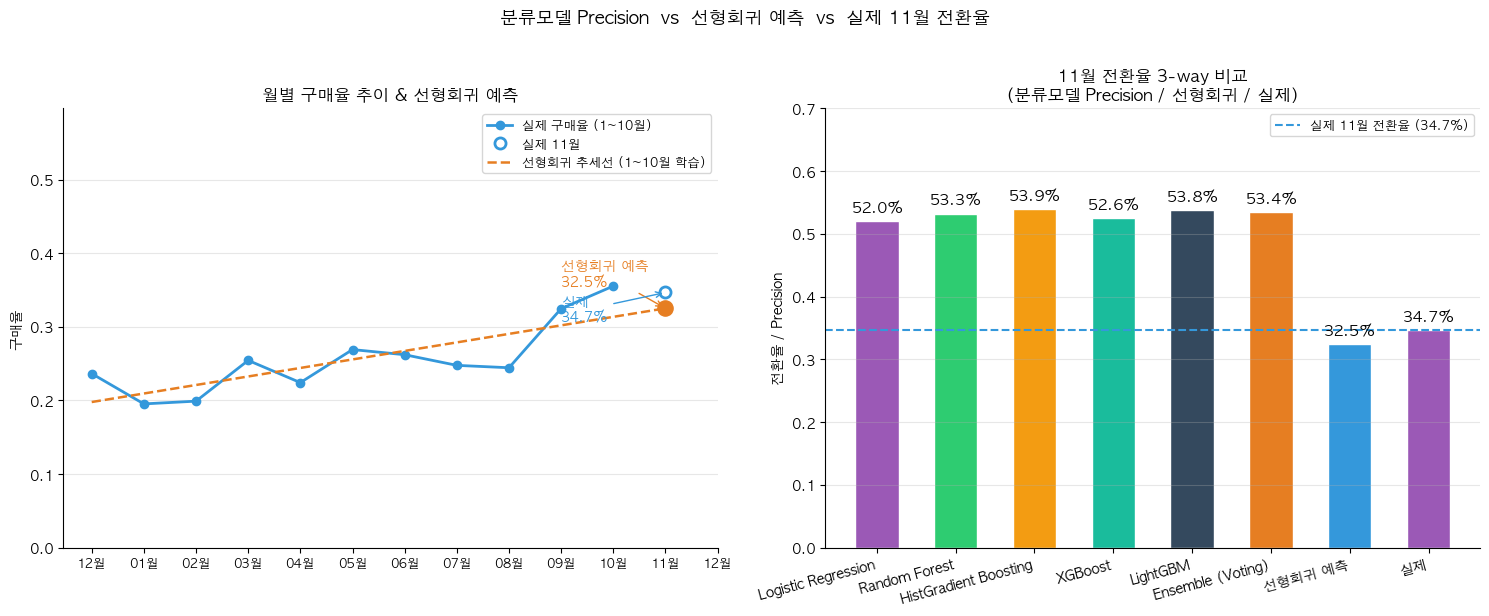

In [20]:
# ============================================================
# Cell 19 : 3-way 비교 — 분류모델 vs 선형회귀 vs 실제 전환율
# ============================================================
# 동환오빠 아이디어 기반, 시윤 데이터/모델로 재구현
# 왼쪽: 월별 실제 구매율 추이 + 선형회귀 추세선
# 오른쪽: 분류모델 Precision / 선형회귀 예측 / 실제 11월 전환율 3-way 막대

# ── 1. 월별 구매율 재계산 (전체 기간 — 11월 포함) ──
# 분모: 10월까지 이력 있는 고객 수 (모델 타겟과 동일 기준)
all_customers_total = daily[
    daily['Date'] <= FEATURE_CUTOFF
]['CustomerID'].nunique()

all_periods = (
    daily
    .assign(YearMonth=lambda df: df['Date'].dt.to_period('M'))
    ['YearMonth'].sort_values().unique()
)

full_monthly = []
for idx, period in enumerate(all_periods):
    month_start = period.to_timestamp()
    month_end   = (period + 1).to_timestamp() - pd.Timedelta(days=1)
    buyers = daily[
        (daily['Date'] >= month_start) & (daily['Date'] <= month_end)
    ]['CustomerID'].nunique()
    rate = buyers / all_customers_total
    full_monthly.append({
        'YearMonth' : str(period),
        'month_num' : idx + 1,
        'rate'      : rate,
    })

full_df = pd.DataFrame(full_monthly)

# ── 2. 선형회귀: 1~10월로 학습 → 11월 예측 (Plan B와 동일) ──
train_monthly = full_df[full_df['month_num'] <= len(monthly_df)]
lr_vis = LinearRegression()
lr_vis.fit(train_monthly['month_num'].values.reshape(-1, 1),
           train_monthly['rate'].values)

nov_idx  = len(monthly_df) + 1
pred_nov = float(lr_vis.predict([[nov_idx]])[0])
pred_nov = np.clip(pred_nov, 0, 1)
actual_nov = actual_pos_rate

# ── 3. 분류모델 Precision 수집 ──
model_names_vis = []
model_precs_vis = []
for name, res in test_results.items():
    y_pred_t = (res['y_prob'] >= 0.5).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    model_names_vis.append(name)
    model_precs_vis.append(prec)

# ── 4. 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 왼쪽: 월별 구매율 추이 + 회귀선
ax1 = axes[0]
ax1.plot(train_monthly['month_num'], train_monthly['rate'],
         'o-', color='#3498db', lw=2, ms=6, label='실제 구매율 (1~10월)')

if nov_idx in full_df['month_num'].values:
    ax1.plot([nov_idx], [actual_nov], 'o',
             color='#3498db', ms=8, markerfacecolor='white',
             markeredgewidth=2, label='실제 11월')

x_line = np.linspace(1, nov_idx, 100).reshape(-1, 1)
ax1.plot(x_line, lr_vis.predict(x_line), '--',
         color='#e67e22', lw=1.8, label='선형회귀 추세선 (1~10월 학습)')
ax1.scatter([nov_idx], [pred_nov], color='#e67e22', s=120, zorder=5)

ax1.annotate(f'선형회귀 예측\n{pred_nov*100:.1f}%',
             xy=(nov_idx, pred_nov),
             xytext=(nov_idx - 2, pred_nov + 0.03),
             arrowprops=dict(arrowstyle='->', color='#e67e22'),
             color='#e67e22', fontsize=10)
ax1.annotate(f'실제\n{actual_nov*100:.1f}%',
             xy=(nov_idx, actual_nov),
             xytext=(nov_idx - 2, actual_nov - 0.04),
             arrowprops=dict(arrowstyle='->', color='#3498db'),
             color='#3498db', fontsize=10)

month_labels = list(full_df['YearMonth'])
ax1.set_xticks(full_df['month_num'])
ax1.set_xticklabels([m[-2:] + '월' for m in month_labels], fontsize=9)
ax1.set_ylabel('구매율')
ax1.set_title('월별 구매율 추이 & 선형회귀 예측', fontsize=12, fontweight='bold')
ax1.set_ylim(0, full_df['rate'].max() * 1.4)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# 오른쪽: 3-way 막대
ax2 = axes[1]
all_labels = model_names_vis + ['선형회귀 예측', '실제']
all_values = model_precs_vis + [pred_nov, actual_nov]
palette    = ['#9b59b6', '#2ecc71', '#f39c12', '#1abc9c', '#34495e', '#e67e22', '#3498db']
colors_3way = palette[:len(all_labels)]

bars = ax2.bar(all_labels, all_values,
               color=colors_3way, edgecolor='white', width=0.55)
ax2.bar_label(bars, labels=[f'{v*100:.1f}%' for v in all_values],
              padding=4, fontsize=11, fontweight='bold')
ax2.axhline(actual_nov, color='#3498db', linestyle='--', lw=1.5,
            label=f'실제 11월 전환율 ({actual_nov*100:.1f}%)')
ax2.set_ylabel('전환율 / Precision')
ax2.set_ylim(0, max(all_values) * 1.3)
ax2.set_title('11월 전환율 3-way 비교\n(분류모델 Precision / 선형회귀 / 실제)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
plt.setp(ax2.get_xticklabels(), rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('분류모델 Precision  vs  선형회귀 예측  vs  실제 11월 전환율',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

[Best Model: Logistic Regression]
Threshold               Precision     Recall         F1     예측 1 수
-----------------------------------------------------------------
기본값 (0.5)                  0.5202     0.6187     0.5652        496명
우리 선택 (0.6)                0.6071     0.4077     0.4878        280명 ◀ 선택
F1 최적 (0.42)               0.4783     0.7650     0.5886        667명


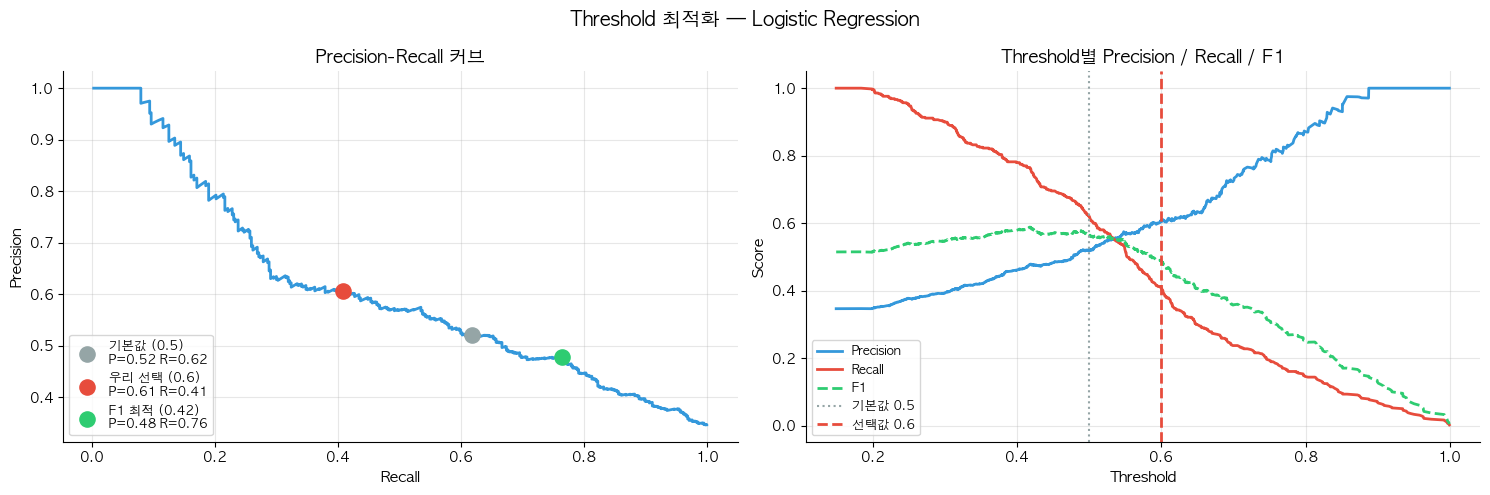


[Threshold 0.6 적용 효과 — Logistic Regression]
  Precision : 0.5202 → 0.6071  (+8.7%p)
  Recall    : 0.6187 → 0.4077  (-21.1%p)
  F1        : 0.5652 → 0.4878  (-7.7%p)
  예측 대상 : 496명 → 280명

[마케팅 해석]
  1,000명에게 쿠폰 발송 시
  기본(0.5) : 약 520명이 실제 구매
  선택(0.6) : 약 607명이 실제 구매  ← 더 효율적

✅ 이후 모든 셀에서 threshold=0.6 적용됨


In [21]:
# ============================================================
# Cell 20 : Threshold 최적화 — Precision 중심
# ============================================================
# 모델 내부 기본값은 threshold=0.5 (확률 ≥ 0.5 → 구매 예측)
# Precision 극대화 목표 → threshold를 높여서 확실한 고객만 선별
# 이 셀 이후로 모든 예측에 THRESHOLD 적용됨

from sklearn.metrics import precision_recall_curve

THRESHOLD = 0.6   # ← 여기서 threshold 조정 가능

y_prob_best = test_results[best_model_name]['y_prob']

# ── 1. Precision-Recall 커브 전체 계산 ──
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_best)

f1_scores = np.where(
    (precisions[:-1] + recalls[:-1]) > 0,
    2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),
    0
)
best_f1_threshold = thresholds[f1_scores.argmax()]

# ── 2. 세 가지 threshold 비교 ──
compare_thresholds = {
    '기본값 (0.5)': 0.5,
    f'우리 선택 ({THRESHOLD})': THRESHOLD,
    f'F1 최적 ({best_f1_threshold:.2f})': best_f1_threshold,
}

print(f'[Best Model: {best_model_name}]')
print(f"{'='*65}")
print(f"{'Threshold':<22} {'Precision':>10} {'Recall':>10} {'F1':>10} {'예측 1 수':>10}")
print(f"{'-'*65}")

threshold_results = {}
for label, thr in compare_thresholds.items():
    y_pred_thr = (y_prob_best >= thr).astype(int)
    tp = ((y_pred_thr == 1) & (y_test == 1)).sum()
    fp = ((y_pred_thr == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thr == 0) & (y_test == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    n_pred = y_pred_thr.sum()
    threshold_results[label] = {
        'threshold': thr, 'precision': prec,
        'recall': rec, 'f1': f1, 'n_pred': n_pred
    }
    marker = ' ◀ 선택' if thr == THRESHOLD else ''
    print(f"{label:<22}  {prec:>9.4f}  {rec:>9.4f}  {f1:>9.4f}  {n_pred:>9,}명{marker}")

print(f"{'='*65}")

# ── 3. 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(recalls[:-1], precisions[:-1], color='#3498db', lw=2)
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall 커브', fontsize=13, fontweight='bold')
colors_thr = ['#95a5a6', '#e74c3c', '#2ecc71']
for (label, res), color in zip(threshold_results.items(), colors_thr):
    ax.scatter(res['recall'], res['precision'], color=color, s=120, zorder=5,
               label=f"{label}\nP={res['precision']:.2f} R={res['recall']:.2f}")
ax.legend(fontsize=9, loc='lower left')
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(thresholds, precisions[:-1], color='#3498db', lw=2, label='Precision')
ax2.plot(thresholds, recalls[:-1],    color='#e74c3c', lw=2, label='Recall')
ax2.plot(thresholds, f1_scores,       color='#2ecc71', lw=2, linestyle='--', label='F1')
ax2.axvline(x=0.5,       color='#95a5a6', linestyle=':', lw=1.5, label='기본값 0.5')
ax2.axvline(x=THRESHOLD, color='#e74c3c', linestyle='--', lw=2, label=f'선택값 {THRESHOLD}')
ax2.set_xlabel('Threshold', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Threshold별 Precision / Recall / F1', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(alpha=0.3)

plt.suptitle(f'Threshold 최적화 — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. 선택 threshold 효과 요약 ──
chosen  = threshold_results[f'우리 선택 ({THRESHOLD})']
default = threshold_results['기본값 (0.5)']
print(f'\n[Threshold {THRESHOLD} 적용 효과 — {best_model_name}]')
print(f'  Precision : {default["precision"]:.4f} → {chosen["precision"]:.4f}  '
      f'({(chosen["precision"]-default["precision"])*100:+.1f}%p)')
print(f'  Recall    : {default["recall"]:.4f} → {chosen["recall"]:.4f}  '
      f'({(chosen["recall"]-default["recall"])*100:+.1f}%p)')
print(f'  F1        : {default["f1"]:.4f} → {chosen["f1"]:.4f}  '
      f'({(chosen["f1"]-default["f1"])*100:+.1f}%p)')
print(f'  예측 대상 : {default["n_pred"]:,}명 → {chosen["n_pred"]:,}명')
print(f'\n[마케팅 해석]')
print(f'  1,000명에게 쿠폰 발송 시')
print(f'  기본(0.5) : 약 {default["precision"]*1000:.0f}명이 실제 구매')
print(f'  선택({THRESHOLD}) : 약 {chosen["precision"]*1000:.0f}명이 실제 구매  ← 더 효율적')
print()
print(f'✅ 이후 모든 셀에서 threshold={THRESHOLD} 적용됨')

In [22]:
# ============================================================
# Cell 21 : 전체 고객 예측 vs 실제 11월 데이터 (threshold 반영)
# ============================================================
best_model = all_models[best_model_name]

X_all   = features[FEATURE_COLS].values
X_all_s = scaler.transform(X_all)

y_prob_all = best_model.predict_proba(X_all_s)[:, 1]
y_pred_all = (y_prob_all >= THRESHOLD).astype(int)  # ← THRESHOLD 적용

pred_df = features[['CustomerID', 'Recency', 'Frequency',
                     'Total_Amount', 'Wait_Ratio', 'Segment', 'Target']].copy()
pred_df['Pred_Prob']  = y_prob_all
pred_df['Pred_Label'] = y_pred_all

full_auc = roc_auc_score(pred_df['Target'], pred_df['Pred_Prob'])
full_f1  = f1_score(pred_df['Target'], pred_df['Pred_Label'], average='binary')
full_prec = (pred_df.loc[pred_df['Pred_Label']==1, 'Target'] == 1).mean() \
            if pred_df['Pred_Label'].sum() > 0 else 0

print(f"[전체 고객 예측 vs 실제 {TARGET_LABEL} | threshold={THRESHOLD}]")
print(f"  전체 고객 수      : {len(pred_df):,}명")
print(f"  실제 구매 O       : {pred_df['Target'].sum():,}명")
print(f"  예측 구매 O       : {pred_df['Pred_Label'].sum():,}명")
print(f"  ROC-AUC          : {full_auc:.4f}")
print(f"  F1 (구매O)       : {full_f1:.4f}")
print(f"  Precision (구매O): {full_prec:.4f}")

print('\n구매 확률 상위 10명:')
display(
    pred_df.sort_values('Pred_Prob', ascending=False)
    .head(10)
    [['CustomerID', 'Pred_Prob', 'Pred_Label', 'Target', 'Recency', 'Wait_Ratio', 'Segment']]
    .assign(Pred_Prob=lambda x: x['Pred_Prob'].round(4))
    .reset_index(drop=True)
)

[전체 고객 예측 vs 실제 11월 구매 여부 | threshold=0.6]
  전체 고객 수      : 4,010명
  실제 구매 O       : 1,390명
  예측 구매 O       : 990명
  ROC-AUC          : 0.7443
  F1 (구매O)       : 0.5319
  Precision (구매O): 0.6394

구매 확률 상위 10명:


,CustomerID,Pred_Prob,Pred_Label,Target,Recency,Wait_Ratio,Segment
0,14911,1.0000,1,1,0,0.000000,4
1,17841,1.0000,1,1,0,0.000000,4
2,12748,0.9999,1,1,3,0.815710,4
3,14646,0.9999,1,1,4,0.488746,4
4,15311,0.9998,1,1,3,0.697885,4
5,13089,0.9996,1,1,1,0.221884,4
6,14606,0.9994,1,1,3,0.697885,4
7,17450,0.9987,1,1,0,0.000000,4
8,18102,0.9987,1,1,10,0.691824,4
9,14156,0.9986,1,1,7,0.880368,4


세그먼트별 예측 성능 (threshold=0.6):
Segment_Name     고객수  실제 구매 O%  예측 구매 O%  평균 예측 확률%  AUC
         VIP  401.00     72.32     95.51      80.29 0.81
      Growth  802.00     50.62     64.71      62.46 0.67
     General 1604.00     29.55      5.49      44.64 0.67
     At Risk 1203.00     18.29      0.00      29.07 0.55


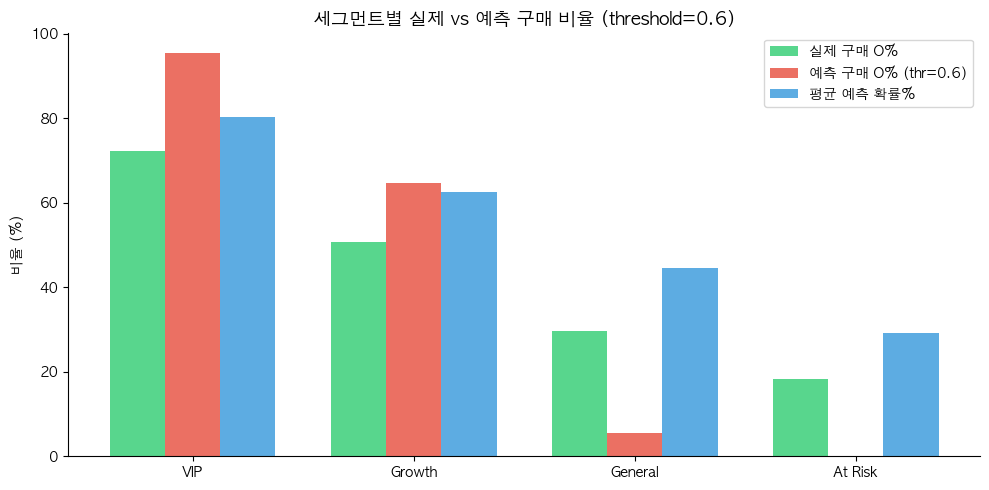

In [23]:
# ============================================================
# Cell 22 : 세그먼트별 예측 정확도 비교 (threshold 반영)
# ============================================================
seg_map = {4: 'VIP', 3: 'Growth', 2: 'General', 1: 'At Risk'}
pred_df['Segment_Name'] = pred_df['Segment'].map(seg_map)

seg_summary = pred_df.groupby('Segment_Name').apply(
    lambda g: pd.Series({
        '고객수'        : len(g),
        '실제 구매 O%'  : g['Target'].mean() * 100,
        '예측 구매 O%'  : g['Pred_Label'].mean() * 100,  # threshold 반영
        '평균 예측 확률%': g['Pred_Prob'].mean() * 100,
        'AUC'           : roc_auc_score(g['Target'], g['Pred_Prob'])
                          if g['Target'].nunique() > 1 else float('nan')
    })
).reset_index()

seg_order = ['VIP', 'Growth', 'General', 'At Risk']
seg_summary['Segment_Name'] = pd.Categorical(
    seg_summary['Segment_Name'], categories=seg_order, ordered=True
)
seg_summary = seg_summary.sort_values('Segment_Name')

print(f'세그먼트별 예측 성능 (threshold={THRESHOLD}):')
print(seg_summary.to_string(index=False, float_format='%.2f'))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(seg_summary))
width = 0.25
ax.bar(x - width, seg_summary['실제 구매 O%'],  width,
       label='실제 구매 O%', color='#2ecc71', alpha=0.8)
ax.bar(x,         seg_summary['예측 구매 O%'],  width,
       label=f'예측 구매 O% (thr={THRESHOLD})', color='#e74c3c', alpha=0.8)
ax.bar(x + width, seg_summary['평균 예측 확률%'], width,
       label='평균 예측 확률%', color='#3498db', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(seg_summary['Segment_Name'])
ax.set_ylabel('비율 (%)')
ax.set_title(f'세그먼트별 실제 vs 예측 구매 비율 (threshold={THRESHOLD})',
             fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# Cell 23 : 모델 요약 — 발표용 테이블 (threshold 반영)
# ============================================================
summary_rows = []
for name, res in test_results.items():
    cv_auc = cv_results[name]['ROC-AUC'].mean() if name in cv_results else float('nan')
    # threshold 0.5 기준 (기존)
    y_pred_05 = res['y_pred']
    f1_05 = f1_score(y_test, y_pred_05, average='binary')
    # threshold THRESHOLD 기준
    y_pred_thr = (res['y_prob'] >= THRESHOLD).astype(int)
    tp = ((y_pred_thr==1) & (y_test==1)).sum()
    fp = ((y_pred_thr==1) & (y_test==0)).sum()
    fn = ((y_pred_thr==0) & (y_test==1)).sum()
    prec_thr = tp/(tp+fp) if (tp+fp)>0 else 0
    rec_thr  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1_thr   = 2*prec_thr*rec_thr/(prec_thr+rec_thr) if (prec_thr+rec_thr)>0 else 0
    summary_rows.append({
        '모델'              : name,
        'CV AUC'           : f'{cv_auc:.4f}',
        'Test AUC'         : f"{res['roc_auc']:.4f}",
        f'Prec (thr={THRESHOLD})' : f'{prec_thr:.4f}',
        f'Rec  (thr={THRESHOLD})' : f'{rec_thr:.4f}',
        f'F1   (thr={THRESHOLD})' : f'{f1_thr:.4f}',
        'F1 (thr=0.5)'     : f'{f1_05:.4f}',
    })

summary_df = pd.DataFrame(summary_rows)
print(f"\n{'='*85}")
print(f"  전체 모델 성능 요약 — {TARGET_LABEL} 예측 | threshold={THRESHOLD} 반영")
print(f"{'='*85}")
print(summary_df.to_string(index=False))
print(f"{'='*85}")
print(f"\n📌 최종 선택 모델 : {best_model_name}")
print(f"   Test AUC       : {test_results[best_model_name]['roc_auc']:.4f}")
print(f"   Precision (thr={THRESHOLD}) : {chosen['precision']:.4f}")
print(f"   Recall    (thr={THRESHOLD}) : {chosen['recall']:.4f}")
print()
print('📌 모델 선택 기준:')
print('   • 불균형 데이터 → ROC-AUC / F1 중심으로 판단')
print(f'   • Precision 극대화 목표 → threshold={THRESHOLD} 적용')
print('   • 마케팅 쿠폰 발송 시 Precision 높을수록 비용 효율 좋음')


  전체 모델 성능 요약 — 11월 구매 여부 예측 | threshold=0.6 반영
                   모델 CV AUC Test AUC Prec (thr=0.6) Rec  (thr=0.6) F1   (thr=0.6) F1 (thr=0.5)
  Logistic Regression 0.7566   0.7128         0.6071         0.4077         0.4878       0.5652
        Random Forest 0.7683   0.7121         0.5870         0.4532         0.5115       0.5587
HistGradient Boosting 0.7608   0.7069         0.5814         0.4796         0.5256       0.5656
              XGBoost 0.7675   0.7070         0.5642         0.5060         0.5335       0.5664
             LightGBM 0.7648   0.7049         0.6000         0.4748         0.5301       0.5593
    Ensemble (Voting) 0.7679   0.7081         0.5811         0.4724         0.5212       0.5630

📌 최종 선택 모델 : Logistic Regression
   Test AUC       : 0.7128
   Precision (thr=0.6) : 0.6071
   Recall    (thr=0.6) : 0.4077

📌 모델 선택 기준:
   • 불균형 데이터 → ROC-AUC / F1 중심으로 판단
   • Precision 극대화 목표 → threshold=0.6 적용
   • 마케팅 쿠폰 발송 시 Precision 높을수록 비용 효율 좋음
